In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
# 1. Load Data
# Load the dataset from the CSV file
data = pd.read_csv('train.csv')
print(data.columns)


Index(['profile pic', 'nums/length username', 'fullname words',
       'nums/length fullname', 'name==username', 'description length',
       'external URL', 'private', '#posts', '#followers', '#follows', 'fake'],
      dtype='object')


In [25]:
# 2. Exploratory Data Analysis (EDA)
# a. Initial Data Check
print("Missing values:\n", data.isnull().sum())
print("\nData Description:\n", data.describe())


Missing values:
 profile pic             0
nums/length username    0
fullname words          0
nums/length fullname    0
name==username          0
description length      0
external URL            0
private                 0
#posts                  0
#followers              0
#follows                0
fake                    0
dtype: int64

Data Description:
        profile pic  nums/length username  fullname words  \
count   576.000000            576.000000      576.000000   
mean      0.701389              0.163837        1.460069   
std       0.458047              0.214096        1.052601   
min       0.000000              0.000000        0.000000   
25%       0.000000              0.000000        1.000000   
50%       1.000000              0.000000        1.000000   
75%       1.000000              0.310000        2.000000   
max       1.000000              0.920000       12.000000   

       nums/length fullname  name==username  description length  external URL  \
count           

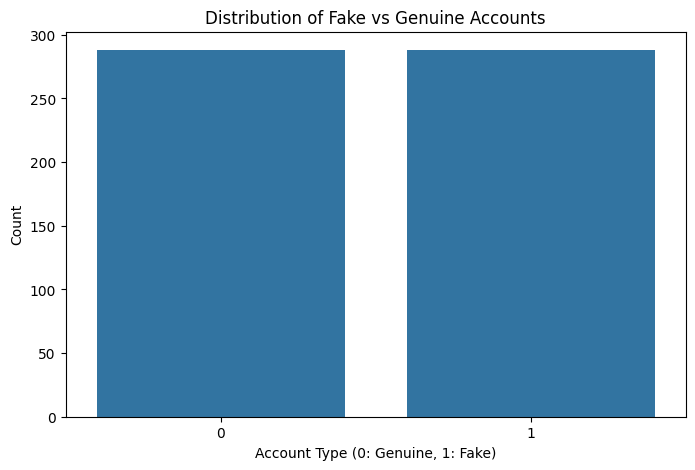

In [8]:
# b. Distribution of Target Variable
plt.figure(figsize=(8, 5))  # Adjust figure size
sns.countplot(x='fake', data=data)
plt.title("Distribution of Fake vs Genuine Accounts")
plt.xlabel("Account Type (0: Genuine, 1: Fake)")
plt.ylabel("Count")
plt.show()

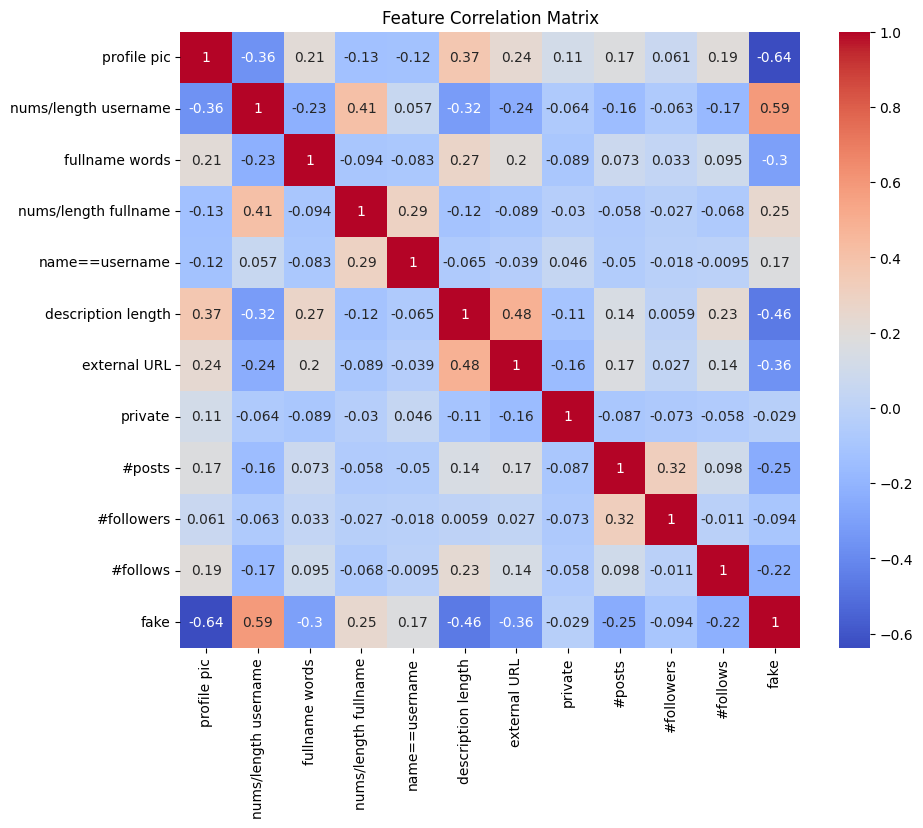

In [7]:
# c. Correlation Analysis
correlation = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

C:\Users\ARJAV JAIN\AppData\Local\Temp\ipykernel_9164\175793812.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='fake', y='profile pic', data=data,ci=None)


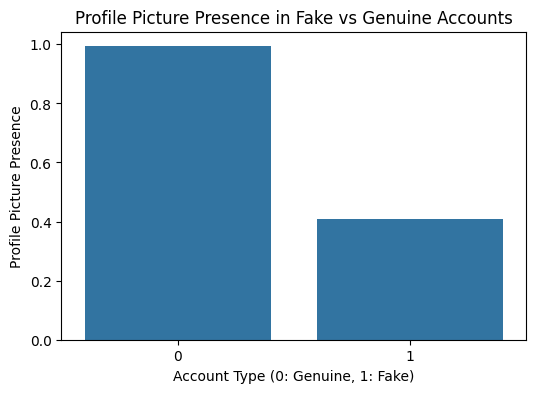

C:\Users\ARJAV JAIN\AppData\Local\Temp\ipykernel_9164\175793812.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='fake', y='#followers', data=data,ci=None)


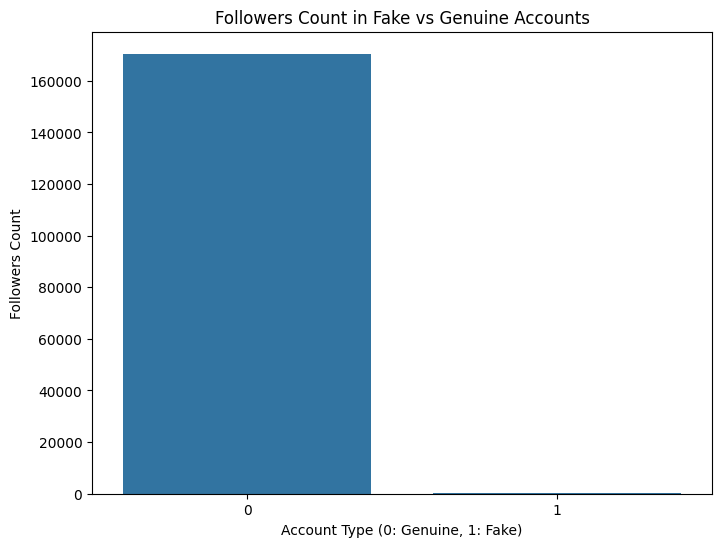

C:\Users\ARJAV JAIN\AppData\Local\Temp\ipykernel_9164\175793812.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='fake', y='#follows', data=data,ci=None)


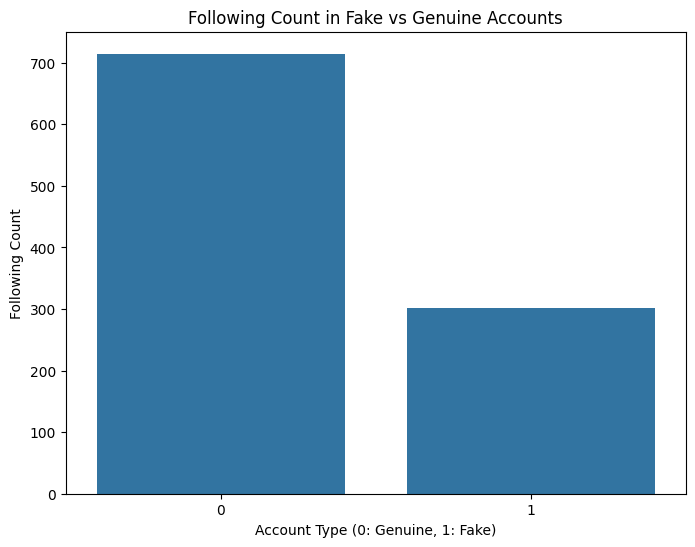

C:\Users\ARJAV JAIN\AppData\Local\Temp\ipykernel_9164\175793812.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='fake', y='#posts', data=data,ci=None)


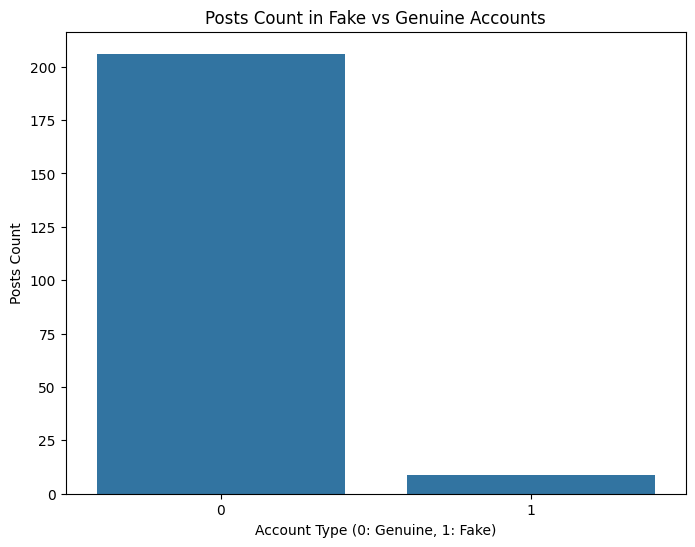

In [8]:


# d. Visualization of Key Features
# i. Profile Picture
plt.figure(figsize=(6, 4))
sns.barplot(x='fake', y='profile pic', data=data,ci=None)
plt.title("Profile Picture Presence in Fake vs Genuine Accounts")
plt.xlabel("Account Type (0: Genuine, 1: Fake)")
plt.ylabel("Profile Picture Presence")
plt.show()

# ii. Followers Count
plt.figure(figsize=(8, 6))
sns.barplot(x='fake', y='#followers', data=data,ci=None)
plt.title("Followers Count in Fake vs Genuine Accounts")
plt.xlabel("Account Type (0: Genuine, 1: Fake)")
plt.ylabel("Followers Count")
plt.show()

# iii. Following Count
plt.figure(figsize=(8, 6))
sns.barplot(x='fake', y='#follows', data=data,ci=None)
plt.title("Following Count in Fake vs Genuine Accounts")
plt.xlabel("Account Type (0: Genuine, 1: Fake)")
plt.ylabel("Following Count")
plt.show()

# iv. Posts Count
plt.figure(figsize=(8, 6))
sns.barplot(x='fake', y='#posts', data=data,ci=None)
plt.title("Posts Count in Fake vs Genuine Accounts")
plt.xlabel("Account Type (0: Genuine, 1: Fake)")
plt.ylabel("Posts Count")
plt.show()

In [15]:
# 3. Data Preprocessing
# Feature Scaling (as in the PDF)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(data.drop('fake', axis=1))
scaled_data = pd.DataFrame(scaled_features, columns=data.columns[:-1])
scaled_data['fake'] = data['fake']

In [16]:
# 4. Model Building
X = scaled_data.drop('fake', axis=1)
y = scaled_data['fake']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

C:\Users\ARJAV JAIN\AppData\Local\Temp\ipykernel_8408\2612006328.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=X.columns[indices], x=importances[indices], palette='viridis')


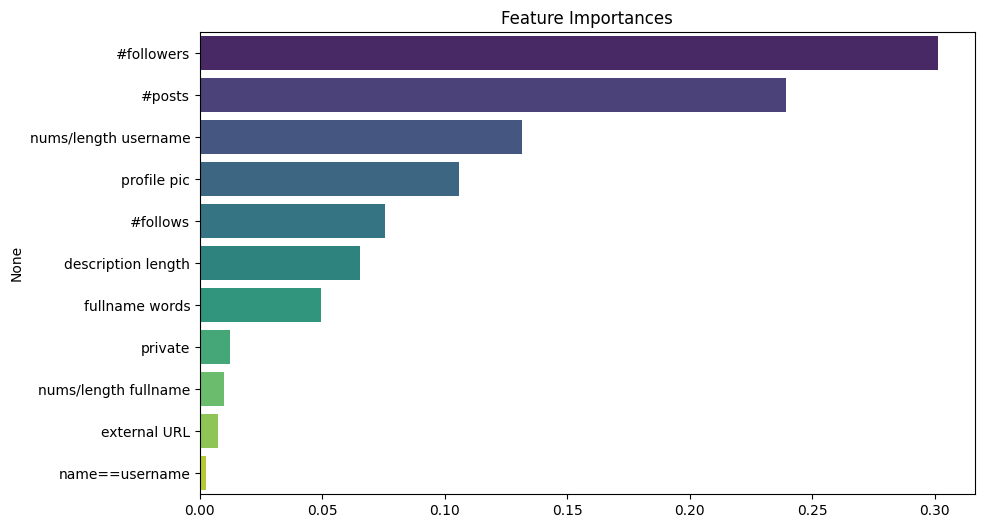

In [17]:
# Feature Importance Plot (as in the PDF)
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
sns.barplot(y=X.columns[indices], x=importances[indices], palette='viridis')
plt.show()

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94        93
           1       0.95      0.90      0.92        80

    accuracy                           0.93       173
   macro avg       0.93      0.93      0.93       173
weighted avg       0.93      0.93      0.93       173

Confusion Matrix:
 [[89  4]
 [ 8 72]]


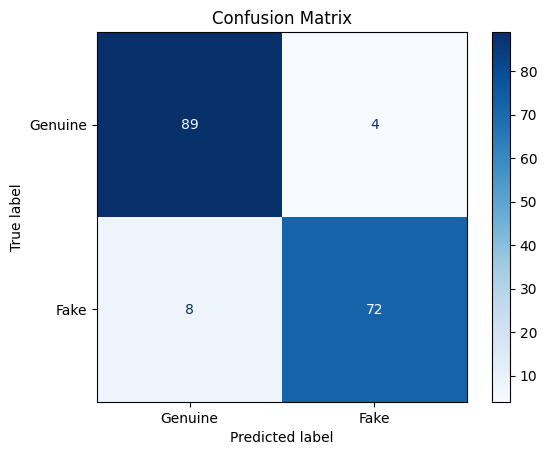

In [18]:
# 5. Model Evaluation
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                      display_labels=['Genuine', 'Fake'],
                                      cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       0.92      1.00      0.96        11

    accuracy                           0.96        24
   macro avg       0.96      0.96      0.96        24
weighted avg       0.96      0.96      0.96        24

Confusion Matrix:
 [[12  1]
 [ 0 11]]
Accuracy: 0.9583333333333334


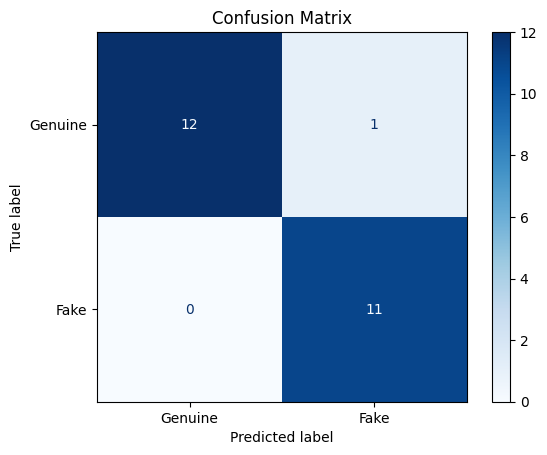

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


# 1. Load Data
data = pd.read_csv('test.csv')

# --- Data Preprocessing (Example) ---
data = data.fillna(0)  # Handle missing values
# ... (Other preprocessing steps)

# Separate features (X) and target (y)
X = data.drop('fake', axis=1)
y = data['fake']

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Model Building
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Model Evaluation
y_pred = model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
                                  display_labels=['Genuine', 'Fake'],
                                  cmap='Blues')
plt.title("Confusion Matrix")
plt.show()